# Extracted Image Features

Here, we experiment with visualizing extracted image features from pre-existing visual foundation models.


## resnet50

In [9]:
import timm
import torch
from PIL import Image
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

# Load a pre-trained model
model = timm.create_model('resnet50', pretrained=True, num_classes=0)  # num_classes=0 removes classification head
model.eval()

# Get the appropriate transforms for this model
config = resolve_data_config({}, model=model)
transform = create_transform(**config)

# Load and transform an image
img = Image.open('data/01_nerf/01_lego_small/r_0.png').convert('RGB')
img_tensor = transform(img).unsqueeze(0)  # Add batch dimension

# Extract features
with torch.no_grad():
    features = model.forward_features(img_tensor)

print(features.shape)  # e.g., torch.Size([1, 2048]) for ResNet50

torch.Size([1, 2048, 7, 7])


In [10]:
features[0, 15, :, :]

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.4276, 1.2513, 0.1882, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 1.5854, 0.4036, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]])

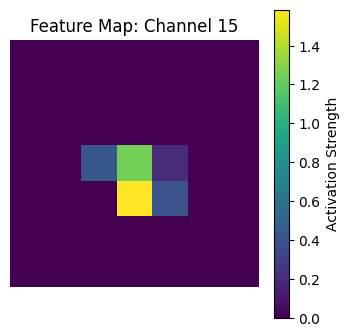

In [15]:
import matplotlib.pyplot as plt

heatmap_data = features[0, 15, :, :].detach().cpu().numpy()

# 2. Plot as a heatmap
plt.figure(figsize=(4, 4))
plt.imshow(heatmap_data, cmap='viridis') # 'viridis', 'magma', or 'jet' are good choices
plt.colorbar(label='Activation Strength')
plt.title('Feature Map: Channel 15')
plt.axis('off') # Clean up axes
plt.show()

## DINOV3

In [16]:
import timm
import torch
from PIL import Image
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

# Load a pre-trained model
# model = timm.create_model('resnet50', pretrained=True, num_classes=0)  # num_classes=0 removes classification head
model = timm.create_model("hf_hub:timm/vit_base_patch16_dinov3.lvd1689m", pretrained=True)
model.eval()

# Get the appropriate transforms for this model
config = resolve_data_config({}, model=model)
transform = create_transform(**config)

# Load and transform an image
img = Image.open('data/01_nerf/01_lego_small/r_0.png').convert('RGB')
img_tensor = transform(img).unsqueeze(0)  # Add batch dimension

# Extract features
with torch.no_grad():
    features = model.forward_features(img_tensor)

print(features.shape)

torch.Size([1, 261, 768])


In [17]:
features[0].shape

torch.Size([261, 768])

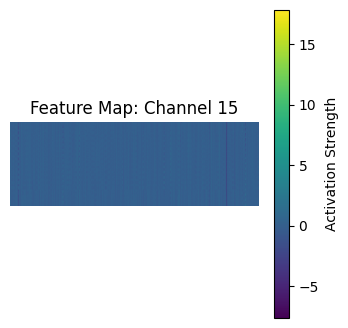

In [18]:
heatmap_data = features[0]
# 2. Plot as a heatmap
plt.figure(figsize=(4, 4))
plt.imshow(heatmap_data, cmap='viridis') # 'viridis', 'magma', or 'jet' are good choices
plt.colorbar(label='Activation Strength')
plt.title('Feature Map: Channel 15')
plt.axis('off') # Clean up axes
plt.show()

In [33]:
# DINOv3 has 1 CLS token + 4 register tokens at the beginning
# Skip the first 5 tokens to get only patch tokens
patch_tokens = features[0, 5:, :]  # Shape: [256, 768]

patch_tokens.shape

torch.Size([256, 768])

In [34]:
import numpy as np
# Determine the spatial grid size
num_patches = patch_tokens.shape[0]
grid_size = int(np.sqrt(num_patches))  # Assuming square grid
grid_size

16

In [35]:
# If it's not a perfect square, you may need to adjust
print(f"Number of patches: {num_patches}, Grid size: {grid_size}x{grid_size}")


Number of patches: 256, Grid size: 16x16


In [36]:
# Reshape to spatial grid: [H, W, C]
patch_grid = patch_tokens[:grid_size*grid_size].reshape(grid_size, grid_size, -1)


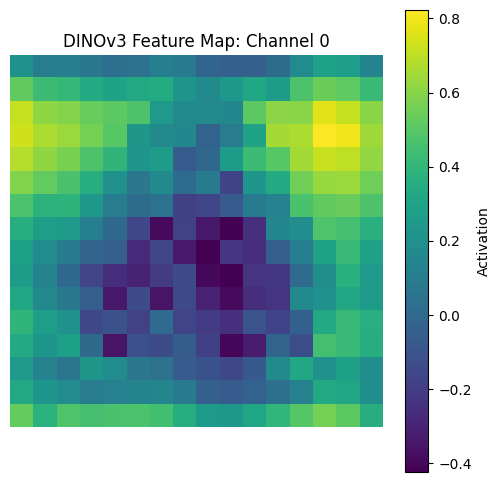

In [40]:
# Visualize a single feature channel
channel_idx = 0
plt.figure(figsize=(6, 6))
plt.imshow(patch_grid[:, :, channel_idx].detach().cpu().numpy(), cmap='viridis')
plt.colorbar(label='Activation')
plt.title(f'DINOv3 Feature Map: Channel {channel_idx}')
plt.axis('off')
plt.show()

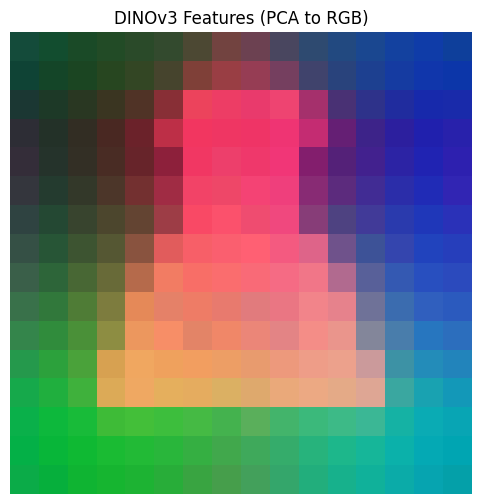

In [38]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# Or visualize using PCA to reduce 768 dims to 3 (RGB)
from sklearn.decomposition import PCA

flat_features = patch_grid.reshape(-1, 768).detach().cpu().numpy()
pca = PCA(n_components=3)
pca_features = pca.fit_transform(flat_features)
pca_features = (pca_features - pca_features.min()) / (pca_features.max() - pca_features.min())
pca_img = pca_features.reshape(grid_size, grid_size, 3)

plt.figure(figsize=(6, 6))
plt.imshow(pca_img)
plt.title('DINOv3 Features (PCA to RGB)')
plt.axis('off')
plt.show()

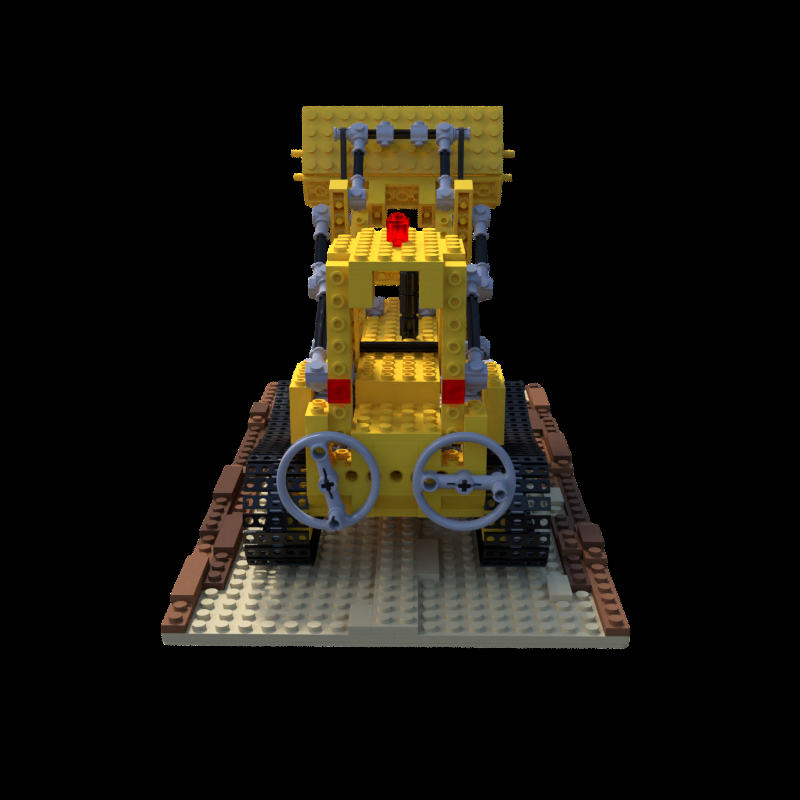

In [39]:
img